Imported Dataset

In [1]:
import gdown
url = "https://drive.google.com/uc?id=1M-o7y6O3Ps3GE1yEpFQy74nP7dy5aijl"
output = "3.csv"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1M-o7y6O3Ps3GE1yEpFQy74nP7dy5aijl
To: /content/3.csv
100%|██████████| 100k/100k [00:00<00:00, 53.0MB/s]


'3.csv'

Imported Libraries

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Checked if imported dataset is correct or not

In [3]:
df = pd.read_csv("3.csv")
df.head(10)

,Age,Income,Gender,Marital_Status,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn
0,56.0,70201.189680,Female,Married,687.761776,9,12,Desktop,0
1,69.0,51901.897395,Male,Single,712.617115,3,14,Tablet,0
2,46.0,38605.409293,Male,Married,782.299643,5,8,Mobile,0
3,32.0,49949.736955,Female,Single,697.749518,7,1,Tablet,0
4,NaN,48965.290095,Other,Married,663.155216,4,4,Desktop,1
5,25.0,11326.768555,Female,Divorced,697.061084,1,4,Desktop,1
6,38.0,41579.497114,NaN,Divorced,687.615220,5,6,Tablet,1
7,56.0,54713.055994,Female,Married,714.708713,7,12,Tablet,0
8,36.0,43636.766522,Male,Divorced,540.098369,3,12,Desktop,0
9,40.0,40306.859573,Male,Divorced,NaN,3,2,Mobile,0


Checked info


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1425 non-null   float64
 1   Income            1425 non-null   float64
 2   Gender            1425 non-null   object 
 3   Marital_Status    1500 non-null   object 
 4   Credit_Score      1425 non-null   float64
 5   Num_Purchases     1500 non-null   int64  
 6   Membership_Years  1500 non-null   int64  
 7   Device_Used       1500 non-null   object 
 8   Churn             1500 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 105.6+ KB


Numerical columns

In [5]:
#numerical
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['Age', 'Income', 'Credit_Score', 'Num_Purchases', 'Membership_Years',
       'Churn'],
      dtype='object')


Catagorical Columns

In [6]:
#categorical
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Gender', 'Marital_Status', 'Device_Used'], dtype='object')


Numerical columns description


In [7]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1425.0,43.750175,15.026126,18.000000,31.000000,44.000000,56.000000,69.000000
Income,1425.0,50446.150664,15320.475325,-826.421240,40557.251779,50671.503006,60994.627689,98819.709397
Credit_Score,1425.0,648.786794,69.583710,390.384237,601.996211,650.015506,694.954684,906.039126
Num_Purchases,1500.0,5.078667,2.260653,0.000000,3.000000,5.000000,6.000000,16.000000
Membership_Years,1500.0,7.388667,3.974603,1.000000,4.000000,7.000000,11.000000,14.000000
Churn,1500.0,0.495333,0.500145,0.000000,0.000000,0.000000,1.000000,1.000000


Catagorical columns description

In [8]:
df[categorical_cols].describe().T

,count,unique,top,freq
Gender,1425,3,Other,486
Marital_Status,1500,3,Divorced,522
Device_Used,1500,3,Desktop,528


Data Visualisation

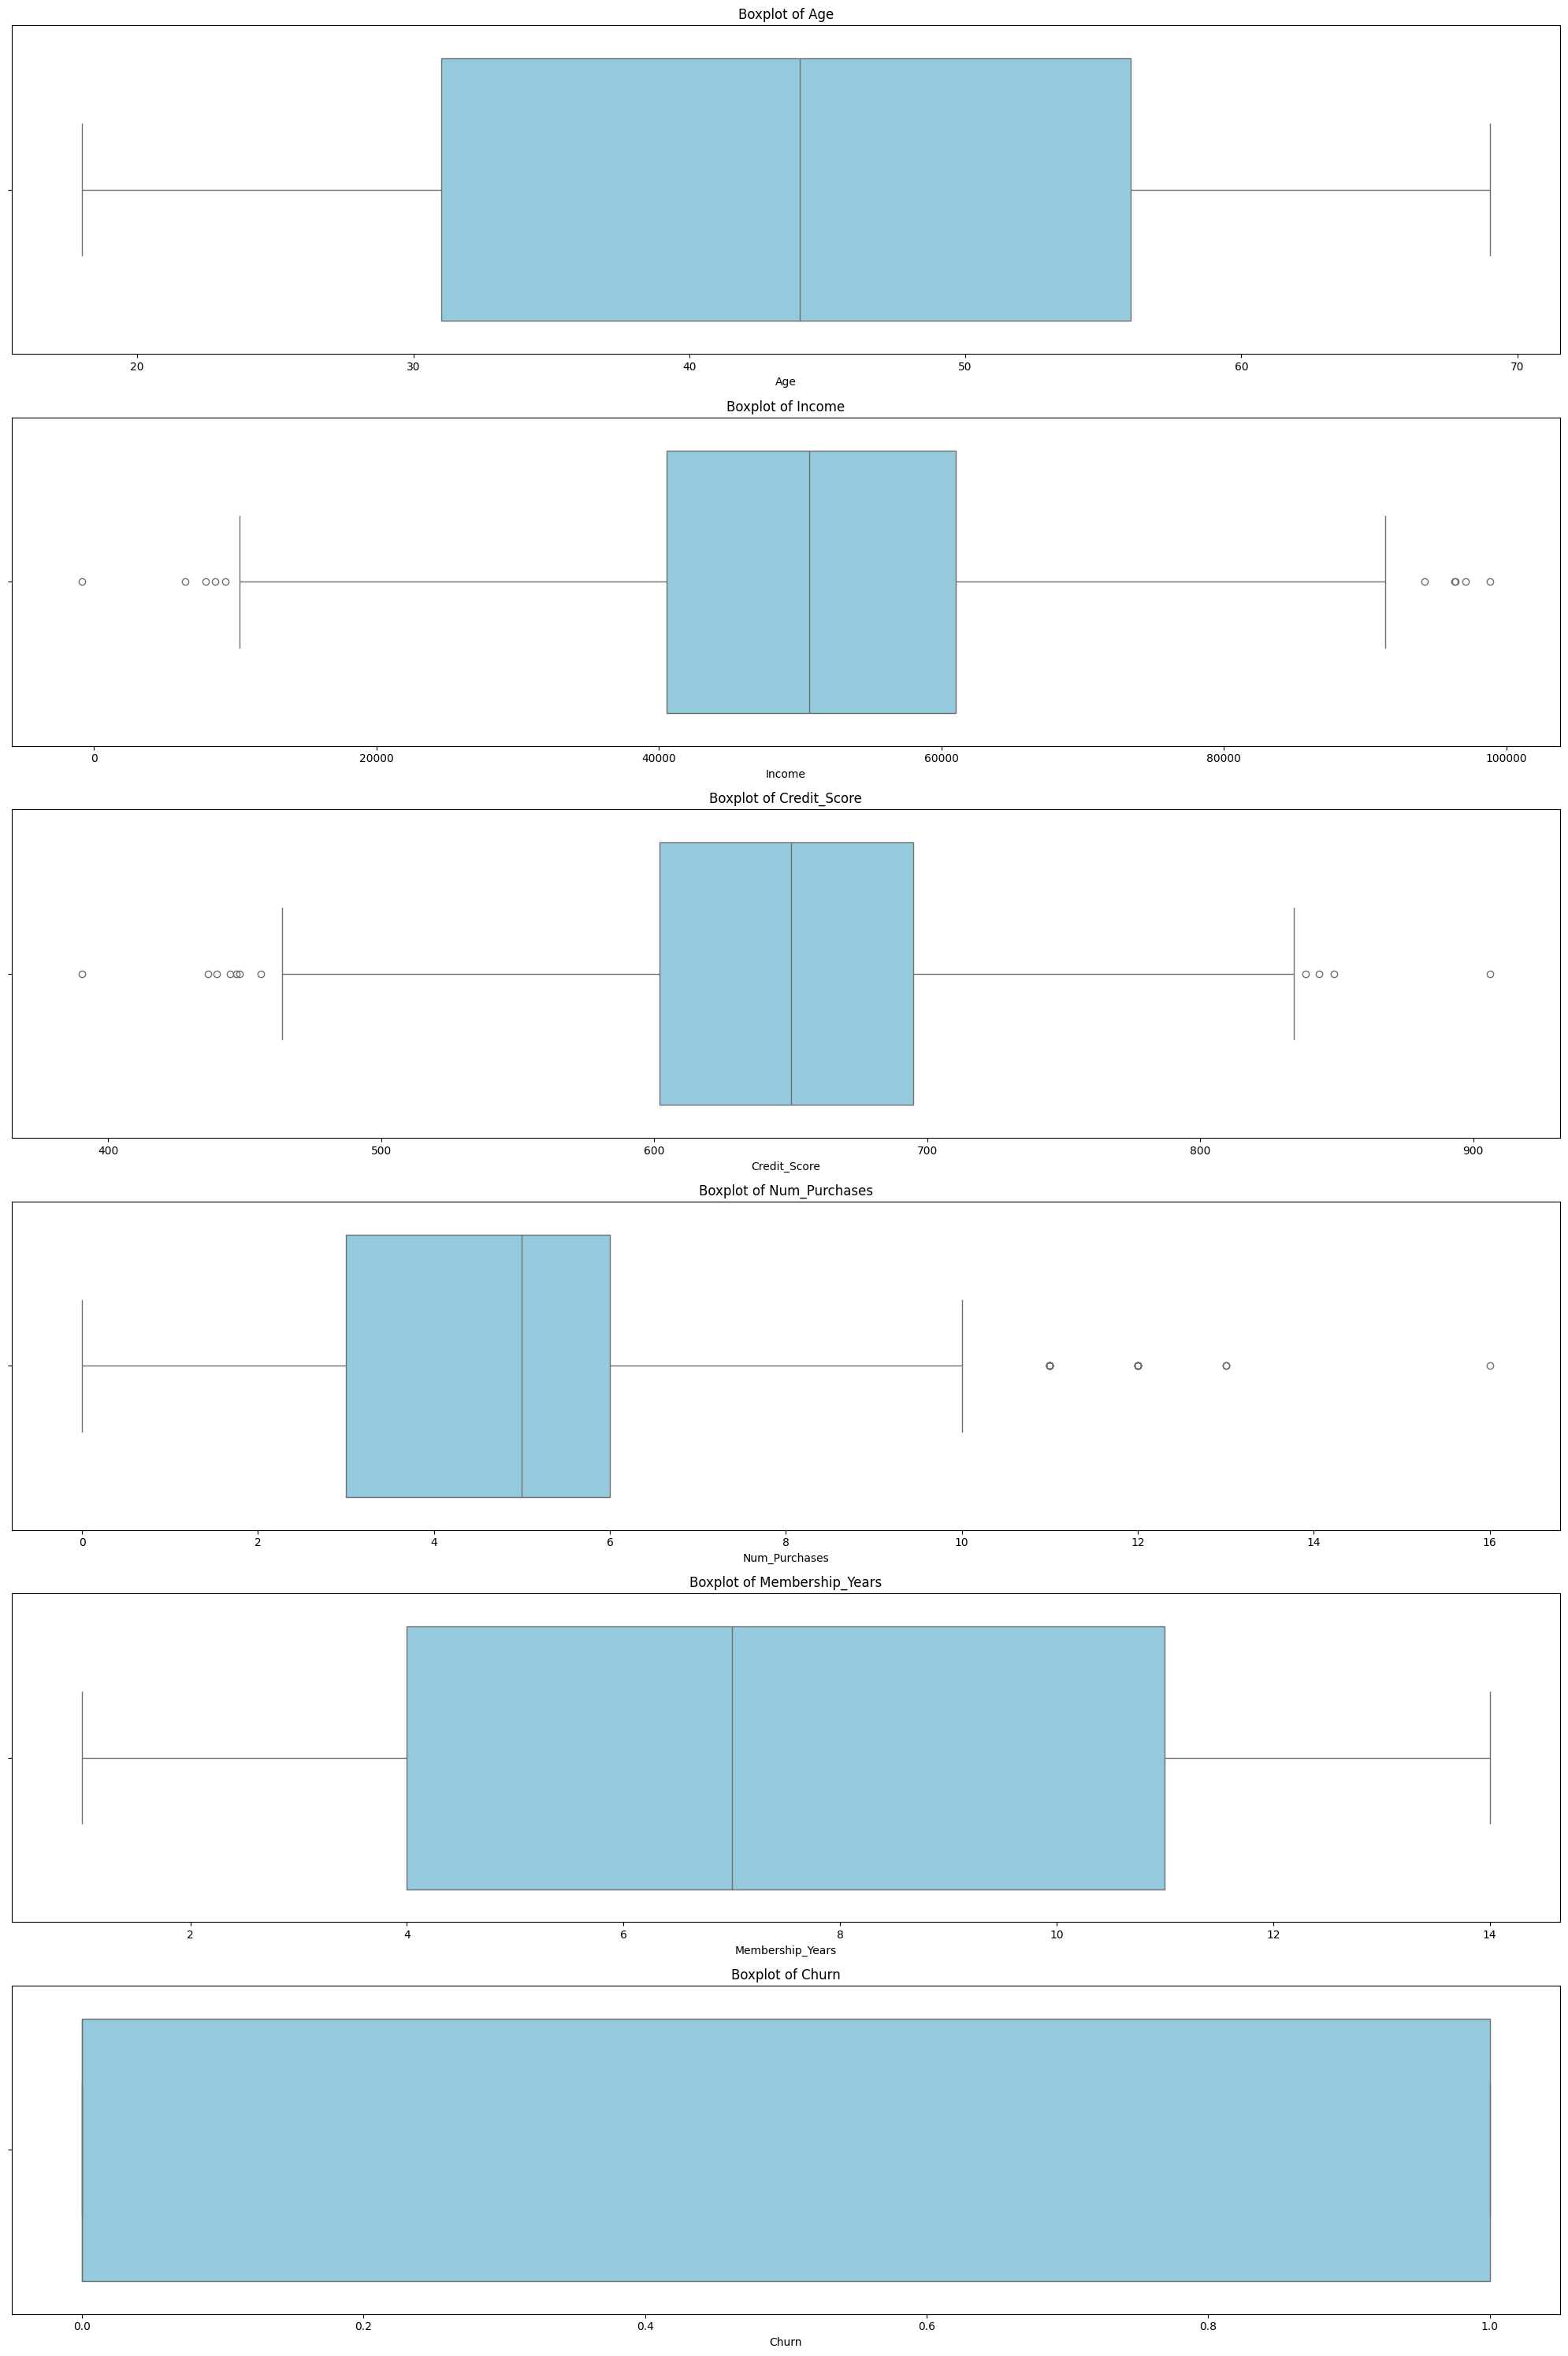

In [9]:
#box plots for numerical data
plt.figure(figsize=(20, 30))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

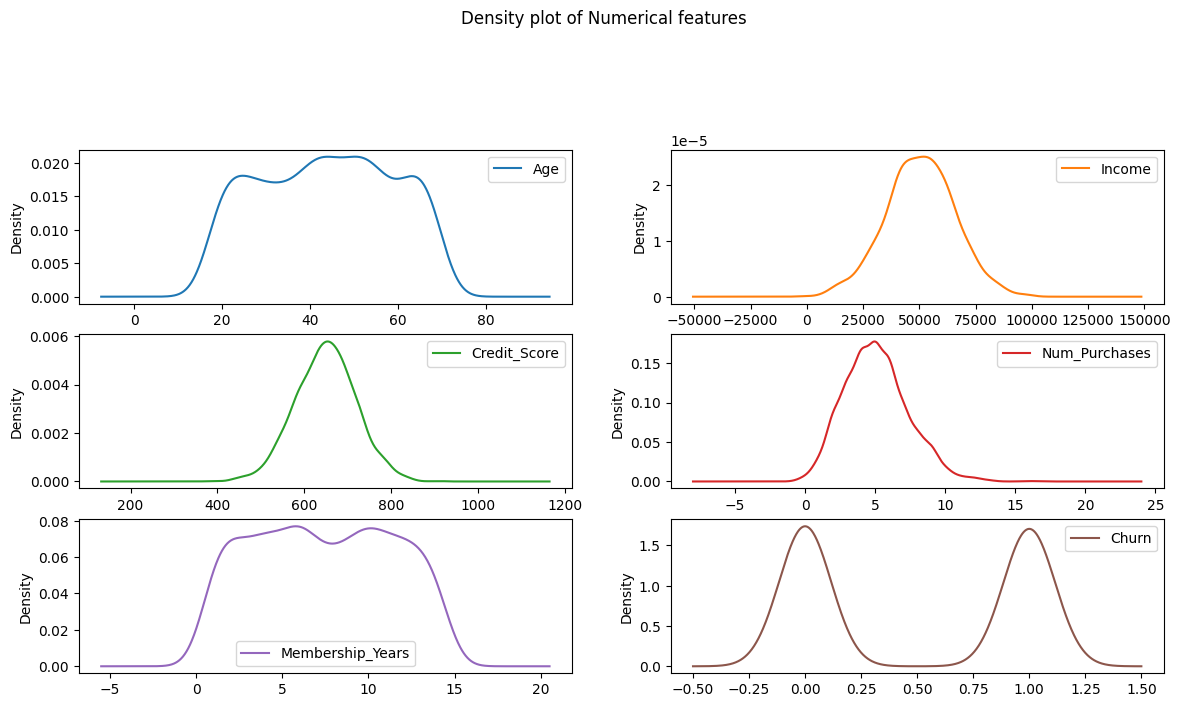

In [10]:
#density graph for numerical data
df[numerical_cols].plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

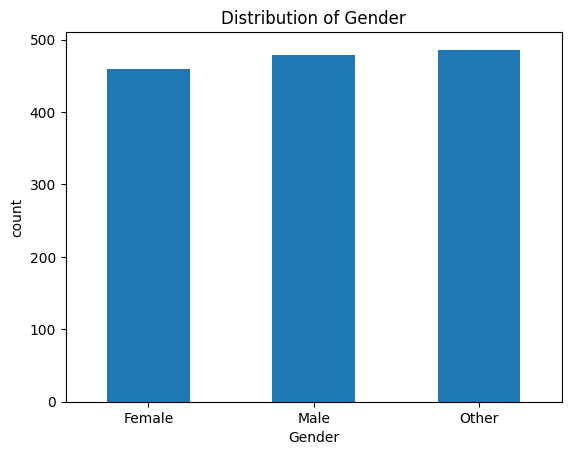

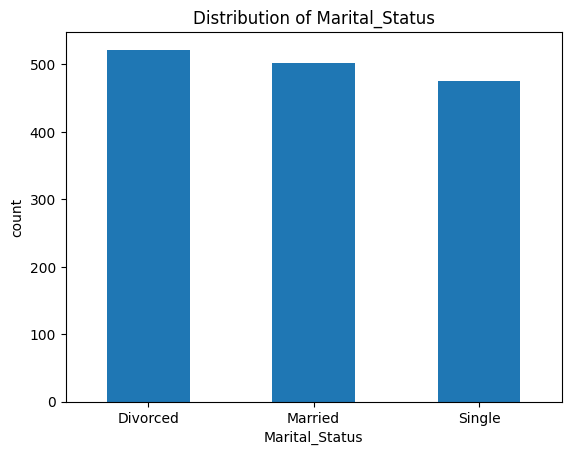

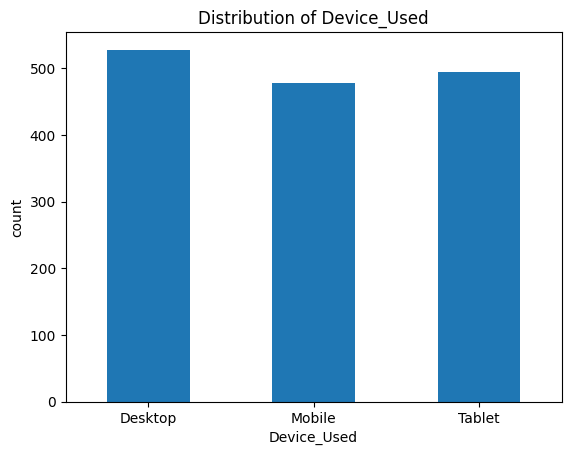

In [11]:
#bar graphs for categorical data
for col in categorical_cols:
    plt.title(f'Distribution of {col}')
    df[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

Data Preprocessing and Feature Encoding

In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Re-load df and re-define categorical_cols to ensure consistency
df = pd.read_csv("3.csv") # Reload the original dataframe
categorical_cols = df.select_dtypes(include=['object']).columns

#label encoding
le = LabelEncoder()
for col in categorical_cols:
    if col != 'Marital_Status': # Apply label encoding to 'Gender' and 'Device_Used'
        df[col] = le.fit_transform(df[col])
#one hot encoding
if 'Marital_Status' in df.columns:
    df = pd.get_dummies(df, columns=["Marital_Status"])

df.head(10)

,Age,Income,Gender,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single
0,56.0,70201.189680,0,687.761776,9,12,0,0,False,True,False
1,69.0,51901.897395,1,712.617115,3,14,2,0,False,False,True
2,46.0,38605.409293,1,782.299643,5,8,1,0,False,True,False
3,32.0,49949.736955,0,697.749518,7,1,2,0,False,False,True
4,NaN,48965.290095,2,663.155216,4,4,0,1,False,True,False
5,25.0,11326.768555,0,697.061084,1,4,0,1,True,False,False
6,38.0,41579.497114,3,687.615220,5,6,2,1,True,False,False
7,56.0,54713.055994,0,714.708713,7,12,2,0,False,True,False
8,36.0,43636.766522,1,540.098369,3,12,0,0,True,False,False
9,40.0,40306.859573,1,NaN,3,2,1,0,True,False,False


In [13]:
df.isnull().sum()

,0
Age,75
Income,75
Gender,0
Credit_Score,75
Num_Purchases,0
Membership_Years,0
Device_Used,0
Churn,0
Marital_Status_Divorced,0
Marital_Status_Married,0


In [14]:
#handle null values using imputer
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='mean')
for col in df:
    if df[col].isnull().sum() > 0:
        impute.fit(df[[col]])
        df[col] = impute.transform(df[[col]])

In [15]:
df.head(10)

,Age,Income,Gender,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single
0,56.000000,70201.189680,0,687.761776,9,12,0,0,False,True,False
1,69.000000,51901.897395,1,712.617115,3,14,2,0,False,False,True
2,46.000000,38605.409293,1,782.299643,5,8,1,0,False,True,False
3,32.000000,49949.736955,0,697.749518,7,1,2,0,False,False,True
4,43.750175,48965.290095,2,663.155216,4,4,0,1,False,True,False
5,25.000000,11326.768555,0,697.061084,1,4,0,1,True,False,False
6,38.000000,41579.497114,3,687.615220,5,6,2,1,True,False,False
7,56.000000,54713.055994,0,714.708713,7,12,2,0,False,True,False
8,36.000000,43636.766522,1,540.098369,3,12,0,0,True,False,False
9,40.000000,40306.859573,1,648.786794,3,2,1,0,True,False,False


In [16]:
# HANDLE DUPLICATE VALUES
# Check the number of duplicate rows before dropping
print(f"Number of duplicate rows before: {df.duplicated().sum()}")

# Drop the duplicate rows
df = df.drop_duplicates()

# Verify duplicates have been removed
print(f"Number of duplicate rows after: {df.duplicated().sum()}")
print(f"New dataset shape: {df.shape}")

Number of duplicate rows before: 0
Number of duplicate rows after: 0
New dataset shape: (1500, 11)


In [17]:
#correlation matrix
df.corr()

,Age,Income,Gender,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single
Age,1.000000,0.014974,-0.020355,-0.010247,0.025287,-0.018593,-0.004760,0.006045,0.024440,-0.035013,0.010485
Income,0.014974,1.000000,0.031886,0.012983,-0.009326,0.009239,0.011834,0.025951,0.028885,0.000784,-0.030356
Gender,-0.020355,0.031886,1.000000,0.045084,-0.037811,-0.019753,0.024127,0.007113,-0.020515,0.018912,0.001821
Credit_Score,-0.010247,0.012983,0.045084,1.000000,0.000837,0.010999,0.032684,0.019468,-0.012383,-0.005584,0.018334
Num_Purchases,0.025287,-0.009326,-0.037811,0.000837,1.000000,0.032381,0.047077,-0.032126,0.020398,-0.030940,0.010492
Membership_Years,-0.018593,0.009239,-0.019753,0.010999,0.032381,1.000000,0.011838,0.001416,0.006381,-0.012129,0.005766
Device_Used,-0.004760,0.011834,0.024127,0.032684,0.047077,0.011838,1.000000,0.040144,-0.020639,-0.026748,0.048240
Churn,0.006045,0.025951,0.007113,0.019468,-0.032126,0.001416,0.040144,1.000000,-0.009977,0.043354,-0.033744
Marital_Status_Divorced,0.024440,0.028885,-0.020515,-0.012383,0.020398,0.006381,-0.020639,-0.009977,1.000000,-0.518146,-0.498103
Marital_Status_Married,-0.035013,0.000784,0.018912,-0.005584,-0.030940,-0.012129,-0.026748,0.043354,-0.518146,1.000000,-0.483549


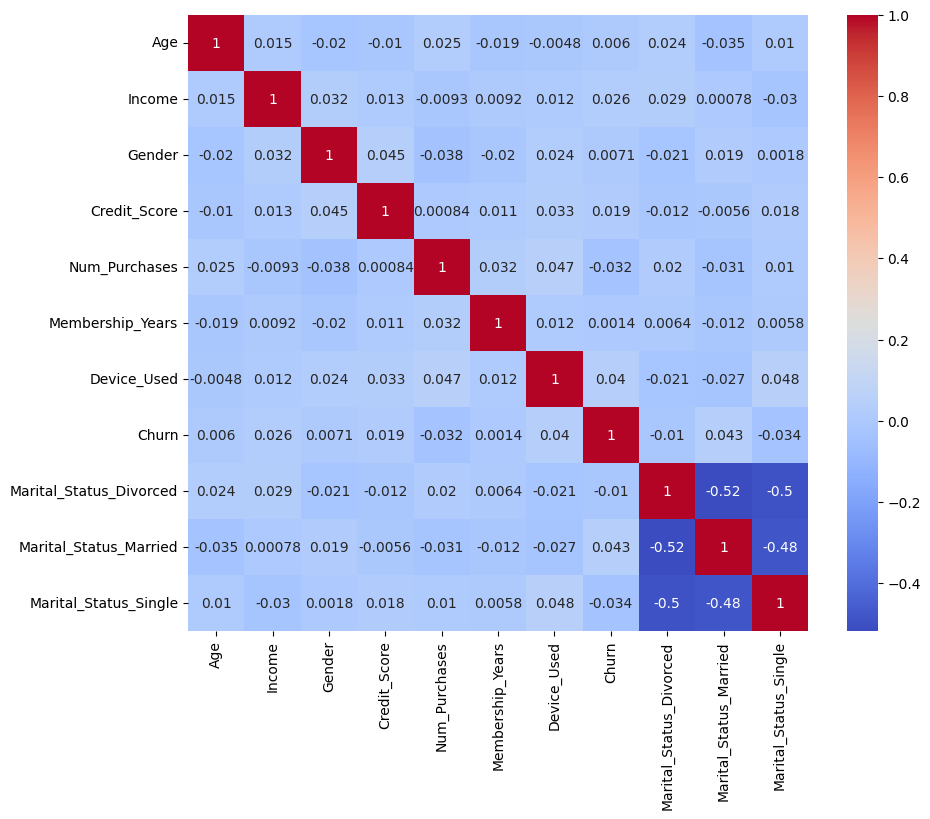

In [18]:
#heatmap for correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [19]:
#feature deletion (using both established knowledge and correlation matrix)
to_delete = ['Marital_Status_Divorced']

for col in to_delete:
    df = df.drop(col, axis=1)
df.shape

(1500, 10)

In [20]:
#feature scaling (using standard due to a medium amount of outliers)
to_scale = ['Age', "Income", "Credit_Score","Num_Purchases", "Membership_Years"]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for col in to_scale:
    df[[col]] = scaler.fit_transform(df[[col]])
df.head(10)

,Age,Income,Gender,Credit_Score,Num_Purchases,Membership_Years,Device_Used,Churn,Marital_Status_Married,Marital_Status_Single
0,8.367072e-01,1.323416,0,0.574869,1.735181,1.160587,0,0,True,False
1,1.724654e+00,0.097522,1,0.941478,-0.919805,1.663949,2,0,False,True
2,1.536711e-01,-0.793227,1,1.969274,-0.034810,0.153861,1,0,True,False
3,-8.025793e-01,-0.033255,0,0.722185,0.850185,-1.607908,2,0,False,True
4,9.706526e-16,-0.099205,2,0.211930,-0.477307,-0.852864,0,1,True,False
5,-1.280705e+00,-2.620658,0,0.712031,-1.804800,-0.852864,0,1,False,False
6,-3.927577e-01,-0.593989,3,0.572707,-0.034810,-0.349502,2,1,False,False
7,8.367072e-01,0.285846,0,0.972328,0.850185,1.160587,2,0,True,False
8,-5.293649e-01,-0.456169,1,-1.603121,-0.919805,1.160587,0,0,False,False
9,-2.561505e-01,-0.679244,1,0.000000,-0.919805,-1.356227,1,0,False,False


In [21]:
#data splitting
# Import the necessary function
from sklearn.model_selection import train_test_split

features = df.drop('Churn', axis=1)
target = df['Churn']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify=target)
unsupervised_train, unsupervised_test = train_test_split(df, test_size=0.3, random_state=42)

In [22]:
#verify stratification
print(target.value_counts(normalize = True))
print(target_test.value_counts(normalize = True))
print(target_train.value_counts(normalize = True))

Churn
0    0.504667
1    0.495333
Name: proportion, dtype: float64
Churn
0    0.504444
1    0.495556
Name: proportion, dtype: float64
Churn
0    0.504762
1    0.495238
Name: proportion, dtype: float64


In [23]:
#KNeigbours
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, recall_score

knn = KNeighborsClassifier()
knn.fit(features_train, target_train)
target_pred_KNeighbours = knn.predict(features_test)

#evaluation scores
accuracy_Kneighbours = accuracy_score(target_test, target_pred_KNeighbours)
precision_Kneighbours = precision_score(target_test, target_pred_KNeighbours, average='weighted')
recall_Kneighbours = recall_score(target_test, target_pred_KNeighbours, average='weighted')
f1_Kneighbours = f1_score(target_test, target_pred_KNeighbours, average='weighted')
print("Accuracy:", accuracy_Kneighbours, "Precision:", precision_Kneighbours, 'Recall:', recall_Kneighbours, 'F1:', f1_Kneighbours)
print(classification_report(target_test, target_pred_KNeighbours))

Accuracy: 0.4777777777777778 Precision: 0.47743386243386243 Recall: 0.4777777777777778 F1: 0.47720703181879875
              precision    recall  f1-score   support

           0       0.48      0.51      0.50       227
           1       0.47      0.44      0.46       223

    accuracy                           0.48       450
   macro avg       0.48      0.48      0.48       450
weighted avg       0.48      0.48      0.48       450



In [24]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dT = DecisionTreeClassifier(random_state=42)
dT.fit(features_train, target_train)
target_pred_DT = dT.predict(features_test)

#evaluation scores
accuracy_DT = accuracy_score(target_test, target_pred_DT)
precision_DT = precision_score(target_test, target_pred_DT, average='weighted')
recall_DT = recall_score(target_test, target_pred_DT, average='weighted')
f1_DT = f1_score(target_test, target_pred_DT, average='weighted')
print("Accuracy:", accuracy_DT, 'Precision:', precision_DT, 'Recall:', recall_DT, 'F1:', f1_DT)
print(classification_report(target_test, target_pred_DT))

Accuracy: 0.5311111111111111 Precision: 0.5311722151987639 Recall: 0.5311111111111111 F1: 0.5311180576474726
              precision    recall  f1-score   support

           0       0.54      0.53      0.53       227
           1       0.53      0.53      0.53       223

    accuracy                           0.53       450
   macro avg       0.53      0.53      0.53       450
weighted avg       0.53      0.53      0.53       450



In [25]:
#Neural Network

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                    max_iter=500, random_state=42)

mlp.fit(features_train, target_train)
target_pred_NN = mlp.predict(features_test)

# evaluation scores
accuracy_NN = accuracy_score(target_test, target_pred_NN)
precision_NN = precision_score(target_test, target_pred_NN, average='weighted')
recall_NN = recall_score(target_test, target_pred_NN, average='weighted')
f1_NN = f1_score(target_test, target_pred_NN, average='weighted')
print("Accuracy:", accuracy_NN, 'Precision:', precision_NN, 'Recall:', recall_NN, 'F1:', f1_NN)
print(classification_report(target_test, target_pred_NN))


Accuracy: 0.48 Precision: 0.47975436302767377 Recall: 0.48 F1: 0.4796401455235685
              precision    recall  f1-score   support

           0       0.49      0.51      0.50       227
           1       0.47      0.45      0.46       223

    accuracy                           0.48       450
   macro avg       0.48      0.48      0.48       450
weighted avg       0.48      0.48      0.48       450



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


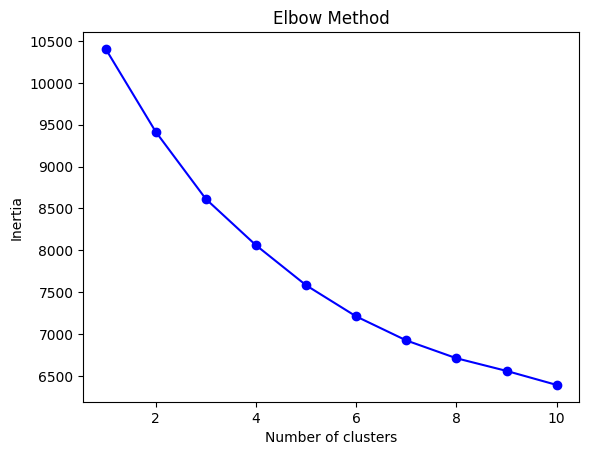

In [26]:
#Elbow method to choose no of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)  # features only
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [27]:
#KMeans clustering (unsupervised)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(features)

# cluster labels
cluster_labels = kmeans.labels_

# silhouette score (measures how well clusters are separated)
sil_score = silhouette_score(features, cluster_labels)
print("KMeans Silhouette Score:", sil_score)

KMeans Silhouette Score: 0.09356566661552133


In [28]:
#collecting results for bar chart
results = {'KNeighbours': {'Accuracy':accuracy_Kneighbours, 'Precision':precision_Kneighbours, 'Recall':recall_Kneighbours, 'F1':f1_Kneighbours},
           'Decision Tree': {'Accuracy':accuracy_DT, 'Precision':precision_DT, 'Recall':recall_DT, 'F1':f1_DT},
           'MLP': {'Accuracy':accuracy_NN, 'Precision':precision_NN, 'Recall': recall_NN, 'F1':f1_NN}}

# Extract metrics
metrics = list(results["Decision Tree"].keys())
DT_scores = list(results["Decision Tree"].values())
KNeighbours_scores = list(results["KNeighbours"].values())
MLP_scores = list(results["MLP"].values())

# Bar positions
x = np.arange(len(metrics))  # metric positions
width = 0.2  # bar width

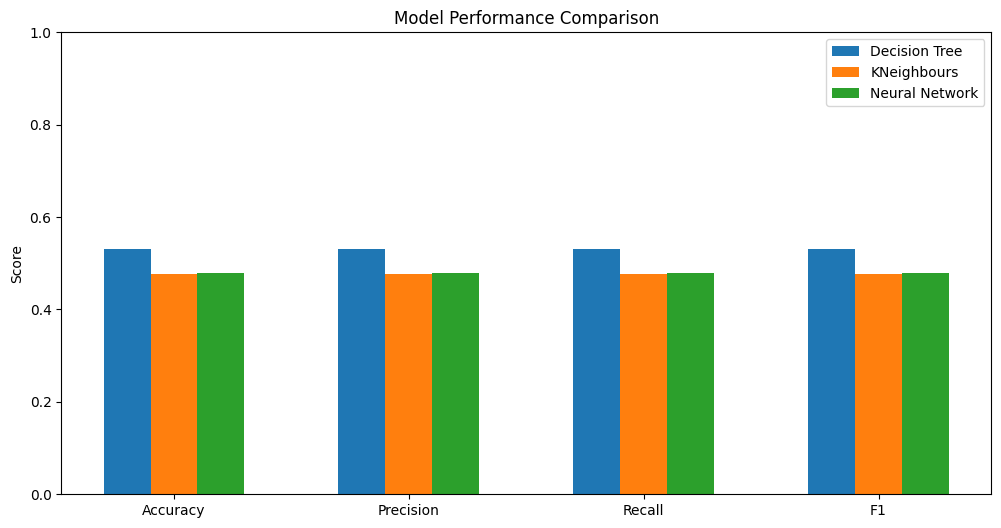

In [29]:
#Bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Bars for DT and KNN
ax.bar(x - width, DT_scores, width, label='Decision Tree')
ax.bar(x, KNeighbours_scores, width, label='KNeighbours')
ax.bar(x+width, MLP_scores, width, label = 'Neural Network')

# Labels and formatting
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Show chart
plt.ylim(0, 1)  # since metrics are between 0 and 1
plt.show()


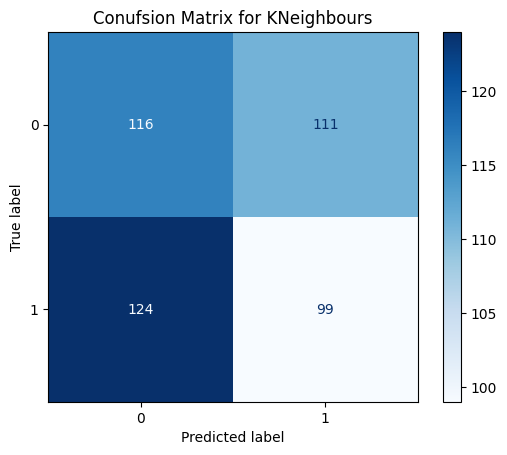

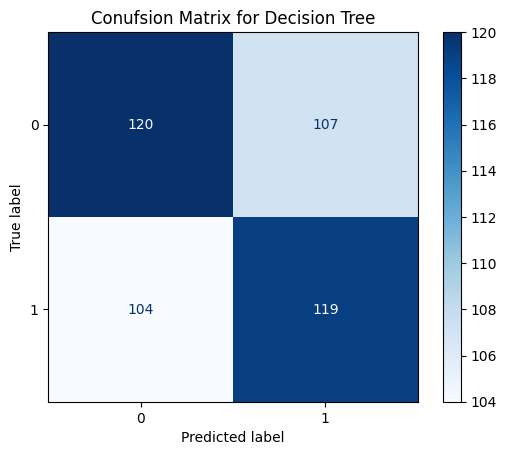

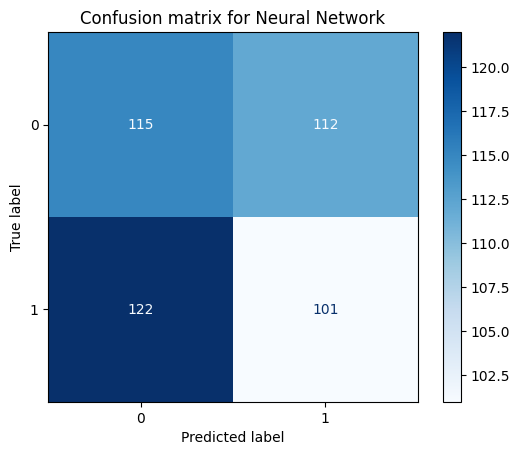

In [30]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#KNN
cm_KNeighbours = confusion_matrix(target_test, target_pred_KNeighbours)
disp_KNeighbours = ConfusionMatrixDisplay(confusion_matrix=cm_KNeighbours, display_labels=knn.classes_)
disp_KNeighbours.plot(cmap='Blues')
plt.title('Conufsion Matrix for KNeighbours')
plt.show()

#Decsion Tree
cm_DT = confusion_matrix(target_test, target_pred_DT)
disp_DT = ConfusionMatrixDisplay(confusion_matrix=cm_DT, display_labels=dT.classes_)
disp_DT.plot(cmap='Blues')
plt.title('Conufsion Matrix for Decision Tree')
plt.show()

#NN
cm_NN = confusion_matrix(target_test, target_pred_NN)
disp_NN = ConfusionMatrixDisplay(confusion_matrix=cm_NN, display_labels=mlp.classes_)
disp_NN.plot(cmap='Blues')
plt.title('Confusion matrix for Neural Network')
plt.show()

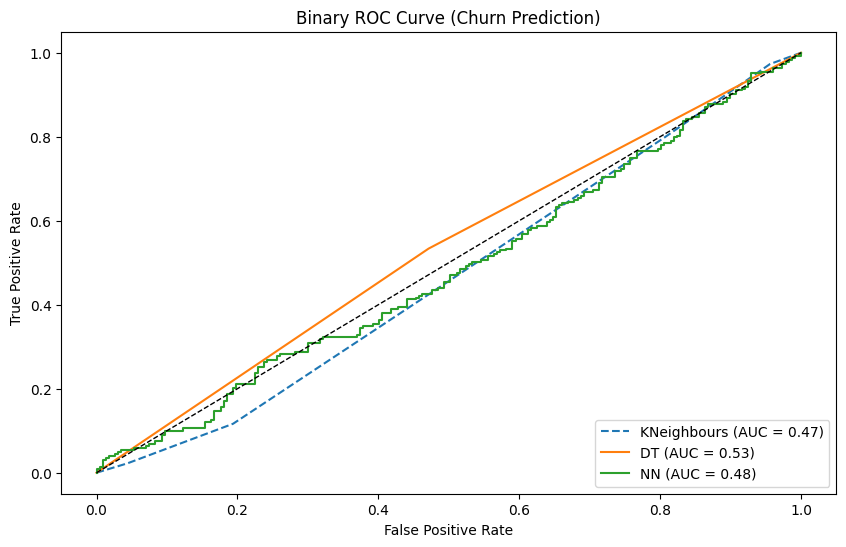

In [31]:
#ROC curve and AUC score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# For binary classification (Churn=0/1), we use the probability of the positive class (index 1)
target_probs_KNN = knn.predict_proba(features_test)[:, 1]
target_probs_DT = dT.predict_proba(features_test)[:, 1]
target_probs_NN = mlp.predict_proba(features_test)[:, 1]

plt.figure(figsize=(10, 6))

# KNN ROC
fpr_KNN, tpr_KNN, _ = roc_curve(target_test, target_probs_KNN)
auc_KNN = auc(fpr_KNN, tpr_KNN)
plt.plot(fpr_KNN, tpr_KNN, linestyle='--', label=f"KNeighbours (AUC = {auc_KNN:.2f})")

# Decision Tree ROC
fpr_DT, tpr_DT, _ = roc_curve(target_test, target_probs_DT)
auc_DT = auc(fpr_DT, tpr_DT)
plt.plot(fpr_DT, tpr_DT, label=f"DT (AUC = {auc_DT:.2f})")

# Neural Network ROC
fpr_NN, tpr_NN, _ = roc_curve(target_test, target_probs_NN)
auc_NN = auc(fpr_NN, tpr_NN)
plt.plot(fpr_NN, tpr_NN, linestyle='-', label=f"NN (AUC = {auc_NN:.2f})")

# Diagonal line for random guess
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary ROC Curve (Churn Prediction)')
plt.legend(loc='lower right')
plt.show()

In [32]:
#Evaluation for KMeans clustering
kmeans.cluster_centers_

array([[ 0.32579041, -0.27371109,  0.93312102, -0.3903595 ,  1.22222156,
         0.37267971,  1.03184713,  0.3343949 ,  0.32484076],
       [-0.74018254,  0.1312566 ,  1.06565657, -0.24593893, -0.2001877 ,
        -0.86430428,  0.96969697,  0.3510101 ,  0.3030303 ],
       [-0.53454565,  0.18543639,  1.27440633,  0.20406753, -0.39674715,
         1.02312478,  0.98680739,  0.33245383,  0.31926121],
       [ 0.9571944 , -0.08835212,  1.16301703,  0.34701487, -0.37502694,
        -0.39542876,  0.93430657,  0.32116788,  0.32360097]])

In [33]:
predictions=kmeans.labels_
print("Prediction for the KMeans Cluster")
print(predictions)
print(len(predictions))

Prediction for the KMeans Cluster
[0 3 3 ... 1 1 1]
1500


UNNECESSARY


In [34]:
# #ROC curve and AUC score
# from sklearn.metrics import roc_curve, auc
# from sklearn.preprocessing import label_binarize

# classes = np.unique(target_test)
# target_test_bin = label_binarize(target_test, classes=classes)

# # Probabilities from models
# target_probs_KNeighbours = knn.predict_proba(features_test)
# target_probs_DT = dT.predict_proba(features_test)
# target_probs_NN = mlp.predict_proba(features_test)

# plt.figure(figsize=(10, 6))

# for i, cls in enumerate(classes):
#     # KNN ROC
#     fpr_KNeighbours, tpr_KNeighbours, _ = roc_curve(target_test_bin[:, i], target_probs_KNeighbours[:, i])
#     auc_KNeighbours = auc(fpr_KNeighbours, tpr_KNeighbours)
#     plt.plot(fpr_KNeighbours, tpr_KNeighbours, linestyle='--', label=f"KNeighbours class {cls} (AUC = {auc_KNeighbours:.2f})")

#     # Decision Tree ROC
#     fpr_DT, tpr_DT, _ = roc_curve(target_test_bin[:, i], target_probs_DT[:, i])
#     auc_DT = auc(fpr_DT, tpr_DT)
#     plt.plot(fpr_DT, tpr_DT, label=f"DT class {cls} (AUC = {auc_DT:.2f})")

#     #Neural Network ROC
#     fpr_NN, tpr_NN, _ = roc_curve(target_test_bin[:, i], target_probs_NN[:, i])
#     auc_NN = auc(fpr_NN, tpr_NN)
#     plt.plot(fpr_NN, tpr_NN, linestyle='-', label=f"NN class {cls} (AUC = {auc_NN:.2f})")
#     # Diagonal line for random guess
#     plt.plot([0, 1], [0, 1], 'k--', lw=1)

# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Multiclass ROC Curve')
# plt.legend(loc='lower right')
# plt.show()